In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


In [2]:
df = pd.read_csv('../data/processed/city_daily_clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['city', 'date']).reset_index(drop=True)

print(f"Loaded: {df.shape}")
print(df['city'].value_counts())
print(df.head())

Loaded: (19018, 17)
city
Bengaluru    4838
Delhi        4838
Mumbai       4838
Hyderabad    4504
Name: count, dtype: int64
        city       date  month  day_of_week  year  quarter  season       PM25  \
0  Bengaluru 2010-01-01      1            4  2010        1  Winter  45.680481   
1  Bengaluru 2010-01-02      1            5  2010        1  Winter  45.680481   
2  Bengaluru 2010-01-03      1            6  2010        1  Winter  51.230321   
3  Bengaluru 2010-01-04      1            0  2010        1  Winter  51.230321   
4  Bengaluru 2010-01-05      1            1  2010        1  Winter  51.230321   

        PM10         NO        NO2        NOx        NH3       SO2        CO  \
0  89.866905   4.014167  19.772083  23.767917  26.069167  1.652000  0.699583   
1  89.866905   5.620625  22.989583  28.594375  25.741042  2.825000  0.695625   
2  92.751640   6.998417  30.434917  37.413889  15.048651  1.764325  0.771427   
3  92.751640  11.967222  31.255972  43.212083  24.080595  6.145159  0.

In [3]:
# prepare data per city
# Features we'll use for LSTM
features = ['PM25', 'PM10', 'NO2', 'NOx', 'SO2', 'CO', 'Ozone', 'month', 'day_of_week', 'season']

# Encode season as number
season_map = {'Winter': 0, 'Spring': 1, 'Monsoon': 2, 'Autumn': 3}
df['season'] = df['season'].map(season_map)

# Check
print("Features selected:", features)
print(df[features].isnull().sum())

Features selected: ['PM25', 'PM10', 'NO2', 'NOx', 'SO2', 'CO', 'Ozone', 'month', 'day_of_week', 'season']
PM25              0
PM10           1765
NO2               0
NOx               0
SO2               0
CO                0
Ozone             0
month             0
day_of_week       0
season            0
dtype: int64


In [4]:
# Function to create sequences
SEQ_LEN = 30  # use 30 past days to predict next day

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len][0])  # PM25 is index 0
    return np.array(X), np.array(y)

print(f"Sequence length: {SEQ_LEN} days")
print("Will predict: PM25 (next day)")

Sequence length: 30 days
Will predict: PM25 (next day)


In [6]:
# Train LSTM for each city
scalers = {}
histories = {}
results = {}

cities = ['Delhi', 'Bengaluru', 'Mumbai', 'Hyderabad']

for city in cities:

    print(f"Training LSTM for {city}...")
    
    
    # Get city data
    city_df = df[df['city'] == city][features].copy()
    city_df = city_df.fillna(city_df.median())
    
    # Scale data
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(city_df)
    scalers[city] = scaler
    
    # Create sequences
    X, y = create_sequences(scaled, SEQ_LEN)
    print(f"Sequences: X={X.shape}, y={y.shape}")
    
    # Train/test split (80/20)
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    print(f"Train: {X_train.shape}, Test: {X_test.shape}")
    
    # Build LSTM model
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, len(features))),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    # Callbacks
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    # Train
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )
    
    histories[city] = history
    
    # Evaluate
    y_pred = model.predict(X_test)
    
    # Inverse transform PM25 only
    def inverse_pm25(values, scaler, n_features):
        dummy = np.zeros((len(values), n_features))
        dummy[:, 0] = values.flatten()
        return scaler.inverse_transform(dummy)[:, 0]
    
    y_test_actual = inverse_pm25(y_test, scaler, len(features))
    y_pred_actual = inverse_pm25(y_pred, scaler, len(features))
    
    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    r2 = r2_score(y_test_actual, y_pred_actual)
    
    results[city] = {
        'model': model,
        'y_test': y_test_actual,
        'y_pred': y_pred_actual,
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    }
    
    print(f"\n {city} Results:")
    print(f"   RMSE : {rmse:.2f}")
    print(f"   MAE  : {mae:.2f}")
    print(f"   R²   : {r2:.4f}")

Training LSTM for Delhi...
Sequences: X=(4808, 30, 10), y=(4808,)
Train: (3846, 30, 10), Test: (962, 30, 10)
Epoch 1/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0062 - mae: 0.0556 - val_loss: 0.0079 - val_mae: 0.0638
Epoch 2/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0029 - mae: 0.0372 - val_loss: 0.0074 - val_mae: 0.0580
Epoch 3/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0023 - mae: 0.0318 - val_loss: 0.0067 - val_mae: 0.0522
Epoch 4/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0022 - mae: 0.0303 - val_loss: 0.0067 - val_mae: 0.0561
Epoch 5/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0022 - mae: 0.0309 - val_loss: 0.0062 - val_mae: 0.0518
Epoch 6/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0021 - mae: 0.0301 - val_loss: 0.0061 - val_mae: 0.0471
Epoch 7/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0020 - mae: 0.0283 - val_loss: 0.0059 - val_mae: 0.0519
Epoch 8/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.001

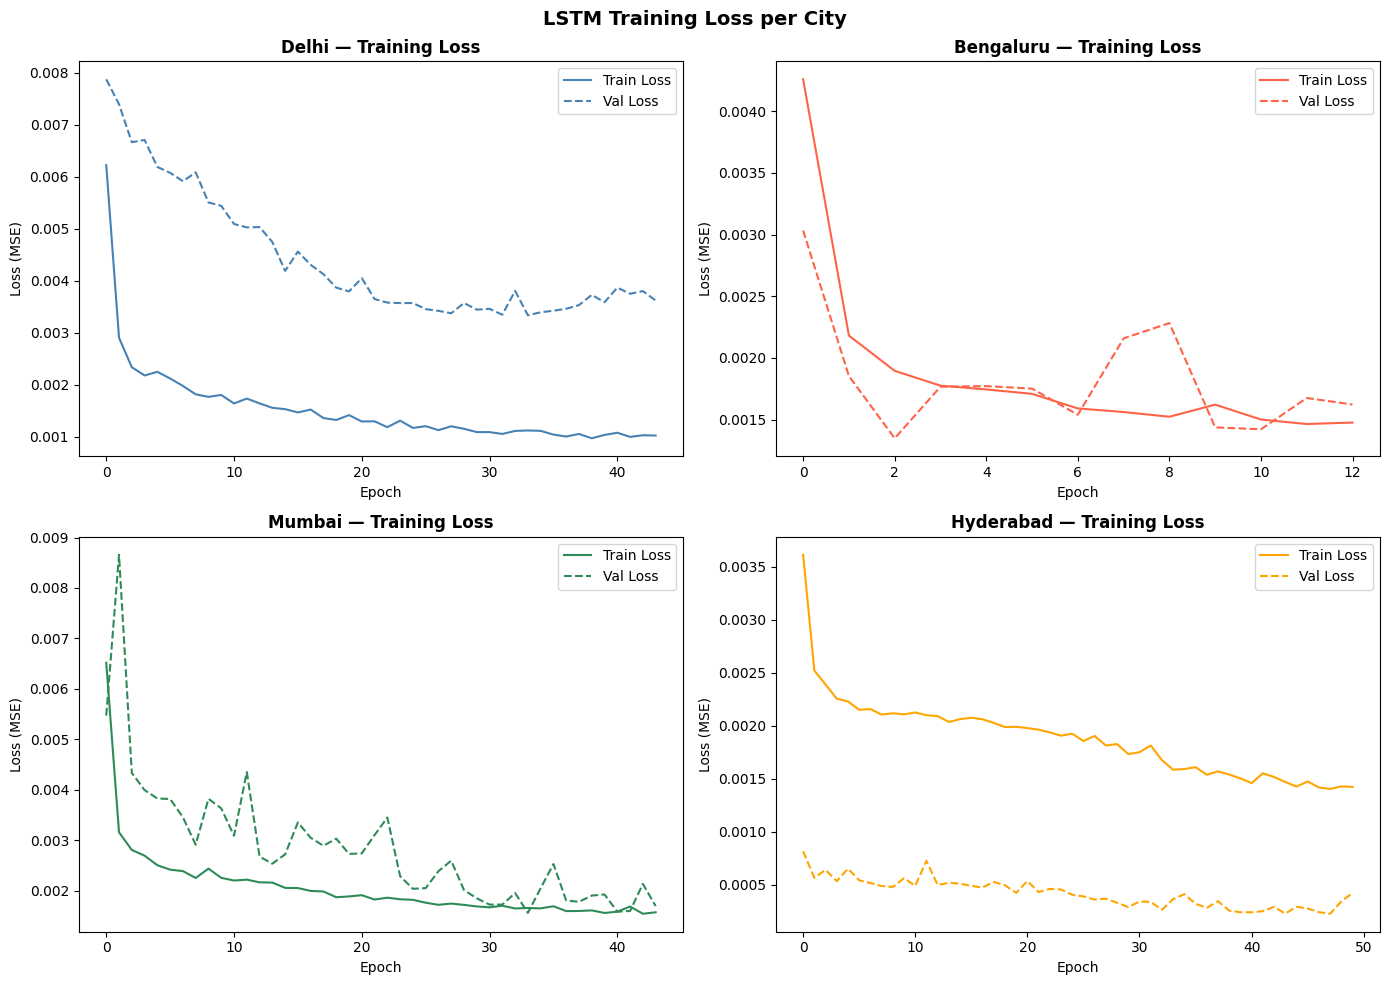

In [7]:
# Plot Training loss
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['steelblue', 'tomato', 'seagreen', 'orange']

for ax, city, color in zip(axes.flatten(), cities, colors):
    ax.plot(histories[city].history['loss'], label='Train Loss', color=color)
    ax.plot(histories[city].history['val_loss'], label='Val Loss', color=color, linestyle='--')
    ax.set_title(f'{city} — Training Loss', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE)')
    ax.legend()

plt.suptitle('LSTM Training Loss per City', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

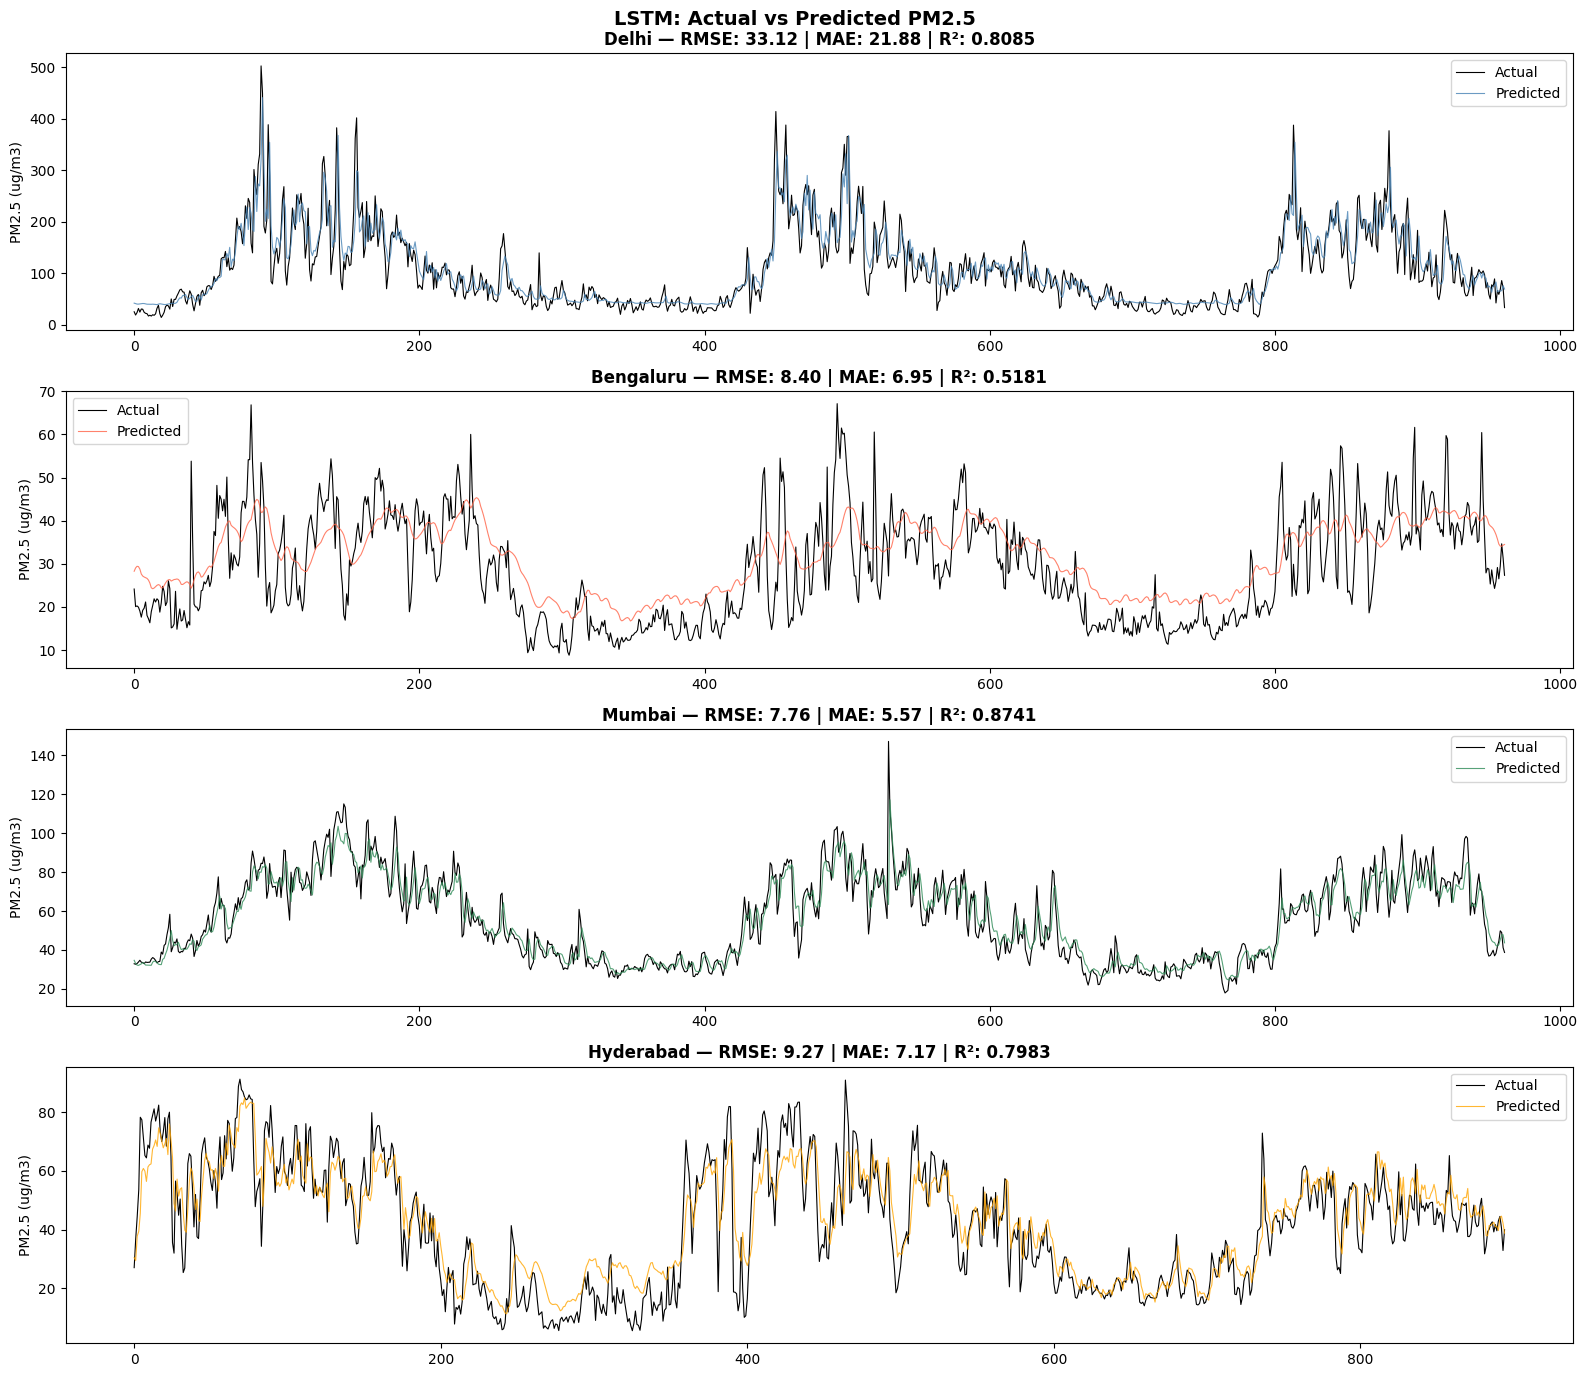

In [8]:
# plot prediction vs actual
fig, axes = plt.subplots(4, 1, figsize=(16, 14))
colors = ['steelblue', 'tomato', 'seagreen', 'orange']

for ax, city, color in zip(axes, cities, colors):
    y_test_actual = results[city]['y_test']
    y_pred_actual = results[city]['y_pred']
    
    ax.plot(y_test_actual, label='Actual', color='black', linewidth=0.8)
    ax.plot(y_pred_actual, label='Predicted', color=color, linewidth=0.8, alpha=0.8)
    ax.set_title(
        f"{city} — RMSE: {results[city]['rmse']:.2f} | MAE: {results[city]['mae']:.2f} | R²: {results[city]['r2']:.4f}",
        fontweight='bold'
    )
    ax.set_ylabel('PM2.5 (ug/m3)')
    ax.legend()

plt.suptitle('LSTM: Actual vs Predicted PM2.5', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Save all models
import os
os.makedirs('../src/models', exist_ok=True)

for city in cities:
    model_path = f'../src/models/lstm_{city.lower()}.keras'
    results[city]['model'].save(model_path)
    print(f"{city} model saved {model_path}")

# Save scalers
import pickle
with open('../src/models/scalers.pkl', 'wb') as f:
    pickle.dump(scalers, f)
print("Scalers saved  src/models/scalers.pkl")

# Print final summary

print("FINAL RESULTS SUMMARY")

for city in cities:
    r = results[city]
    print(f"{city:12} → RMSE: {r['rmse']:6.2f} | MAE: {r['mae']:6.2f} | R²: {r['r2']:.4f}")

Delhi model saved ../src/models/lstm_delhi.keras
Bengaluru model saved ../src/models/lstm_bengaluru.keras
Mumbai model saved ../src/models/lstm_mumbai.keras
Hyderabad model saved ../src/models/lstm_hyderabad.keras
Scalers saved  src/models/scalers.pkl
FINAL RESULTS SUMMARY
Delhi        → RMSE:  33.12 | MAE:  21.88 | R²: 0.8085
Bengaluru    → RMSE:   8.40 | MAE:   6.95 | R²: 0.5181
Mumbai       → RMSE:   7.76 | MAE:   5.57 | R²: 0.8741
Hyderabad    → RMSE:   9.27 | MAE:   7.17 | R²: 0.7983
